In [1]:
import os
import numpy as np
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import torch
import plotly.express as px

# Cell: inspect embedding-layer weights from model_arch.py
# Focus on the token embedding table, including dragon and cave card rows.

import matplotlib.pyplot as plt

from game_env import WyrmspanEnv
from model_arch import WyrmspanAgent

try:
    import torch.nn as nn
except Exception:
    torch = None
    nn = None


def _to_numpy(tensor):
    if torch is not None and isinstance(tensor, torch.Tensor):
        return tensor.detach().cpu().numpy()
    return np.asarray(tensor)


def load_wyrmspan_agent(path, device="cpu"):
    """Load the exact WyrmspanAgent architecture from model_arch.py."""
    if torch is None:
        raise RuntimeError("PyTorch not available to load model file.")

    env = WyrmspanEnv()
    agent = WyrmspanAgent(
        main_emb_dim=256,
        fusion_dim=256,
        action_vocab_size=env.action_token_vocab_size,
        action_pad_id=env.pad_token_id,
        max_action_tokens=env.max_action_tokens,
        max_queue_size=env.max_queue_size,
        max_hand_size=env.max_hand_size,
        dropout=0.0,
    ).to(device)

    checkpoint = torch.load(path, map_location=device)
    state_dict = checkpoint.get("model", checkpoint) if isinstance(checkpoint, dict) else checkpoint
    if not isinstance(state_dict, dict):
        raise RuntimeError("Checkpoint does not contain a loadable model state_dict.")

    agent.load_state_dict(state_dict)
    agent.eval()
    return env, agent, checkpoint


def get_token_embedding_tables(agent, env):
    """Return the full token embedding matrix and token-group slices."""
    token_embeddings = _to_numpy(agent.action_sequence_encoder.action_token_embed.weight)
    token_names = list(env.token_strings)

    dragon_indices = [i for i, name in enumerate(token_names) if name.startswith("dragon_")]
    cave_indices = [i for i, name in enumerate(token_names) if name.startswith("cave_")]
    special_indices = [i for i, name in enumerate(token_names) if not (name.startswith("dragon_") or name.startswith("cave_"))]

    tables = {
        "all_tokens": (token_embeddings, token_names),
        "special_tokens": (token_embeddings[special_indices], [token_names[i] for i in special_indices]),
        "dragon_cards": (token_embeddings[dragon_indices], [token_names[i] for i in dragon_indices]),
        "cave_cards": (token_embeddings[cave_indices], [token_names[i] for i in cave_indices]),
    }
    return tables


def plot_heatmap(weights, title=None, max_rows=200, figsize=(10, 6), cmap="viridis", save_path=None):
    arr = np.asarray(weights)
    if arr.shape[0] > max_rows:
        idx = np.linspace(0, arr.shape[0] - 1, max_rows, dtype=int)
        arr = arr[idx]
    plt.figure(figsize=figsize)
    sns.heatmap(arr, cmap=cmap, xticklabels=False, yticklabels=False)
    if title:
        plt.title(title)
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_pca_scatter(weights, title=None, annotate=10, labels=None, figsize=(6, 5), save_path=None):
    arr = np.asarray(weights)
    pca = PCA(n_components=2)
    proj = pca.fit_transform(arr)
    plt.figure(figsize=figsize)
    plt.scatter(proj[:, 0], proj[:, 1], s=8, alpha=0.7)
    if annotate:
        for i in range(min(annotate, proj.shape[0])):
            label = labels[i] if labels is not None and i < len(labels) else str(i)
            plt.annotate(label, (proj[i, 0], proj[i, 1]), fontsize=8)
    if title:
        plt.title(title)
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close()


def plotly_pca_scatter(weights, title=None, annotate=10, labels=None, save_path=None):
    arr = np.asarray(weights)
    pca = PCA(n_components=2)
    proj = pca.fit_transform(arr)
    df = {
        "PC1": proj[:, 0],
        "PC2": proj[:, 1],
        "label": [labels[i] if labels is not None and i < len(labels) else str(i) for i in range(proj.shape[0])],
    }
    fig = px.scatter(df, x="PC1", y="PC2", text="label", title=title)
    fig.update_traces(textposition="top center")
    fig.update_layout(showlegend=False)
    # if save_path:
    #     fig.write_image(save_path)
    fig.show()


def plot_tsne_scatter(weights, title=None, perplexity=30, n_iter=1000, annotate=10, labels=None, figsize=(6, 5), save_path=None):
    arr = np.asarray(weights)
    ts = TSNE(n_components=2, perplexity=min(perplexity, max(5, arr.shape[0] - 1)), n_iter=n_iter, init="pca", random_state=0)
    proj = ts.fit_transform(arr)
    plt.figure(figsize=figsize)
    plt.scatter(proj[:, 0], proj[:, 1], s=8, alpha=0.7)
    if annotate:
        for i in range(min(annotate, proj.shape[0])):
            label = labels[i] if labels is not None and i < len(labels) else str(i)
            plt.annotate(label, (proj[i, 0], proj[i, 1]), fontsize=8)
    if title:
        plt.title(title)
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close()


def visualize_token_embeddings(source, out_dir="embedding_plots", heatmap_max_rows=200):
    os.makedirs(out_dir, exist_ok=True)

    if isinstance(source, str):
        env, agent, checkpoint = load_wyrmspan_agent(source)
    elif isinstance(source, tuple) and len(source) >= 2:
        env, agent = source[0], source[1]
        checkpoint = source[2] if len(source) > 2 else None
    else:
        raise TypeError("source must be a checkpoint path or (env, agent) tuple")

    tables = get_token_embedding_tables(agent, env)
    for table_name, (weights, names) in tables.items():
        base = table_name.replace("/", "_").replace(" ", "_")
        hm_path = os.path.join(out_dir, f"{base}_heatmap.png")
        pca_path = os.path.join(out_dir, f"{base}_pca.png")
        tsne_path = os.path.join(out_dir, f"{base}_tsne.png")
        plot_heatmap(weights, title=f"{table_name} heatmap", max_rows=heatmap_max_rows, save_path=hm_path)
        plot_pca_scatter(weights, title=f"{table_name} PCA", labels=names, save_path=pca_path)
        plotly_pca_scatter(weights, title=f"{table_name} PCA (Plotly)", labels=names, save_path=pca_path.replace(".png", ".html"))
        # try:
        #     plot_tsne_scatter(weights, title=f"{table_name} t-SNE", labels=names, save_path=tsne_path)
        # except Exception:
        #     pass

    return {
        name: {
            "shape": tuple(weights.shape),
            "sample_tokens": names[:10],
        }
        for name, (weights, names) in tables.items()
    }

C:\Users\tyler\AppData\Local\Temp\ipykernel_12188\3644996547.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location=device)


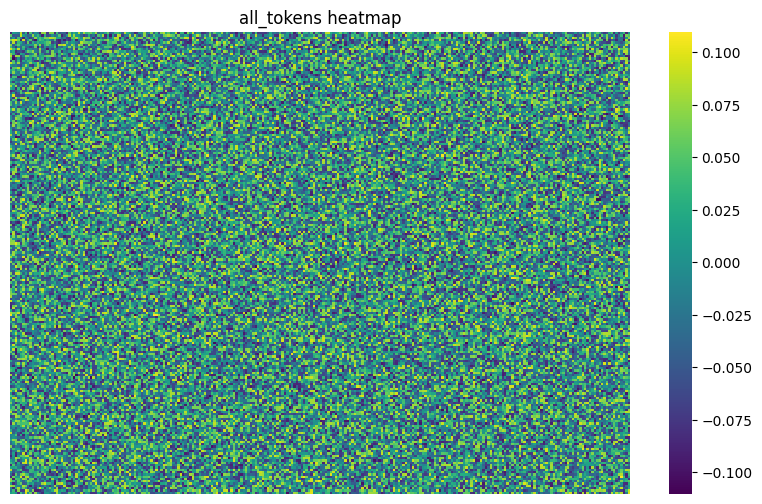

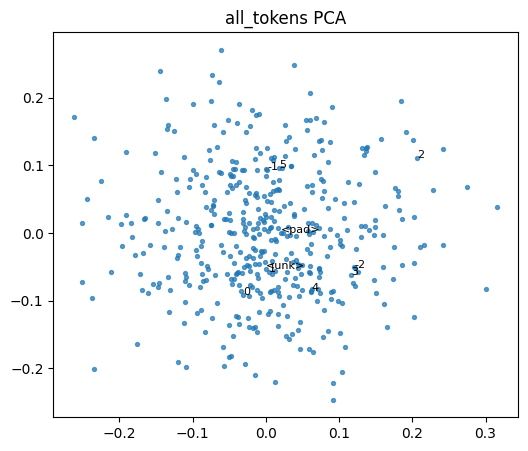

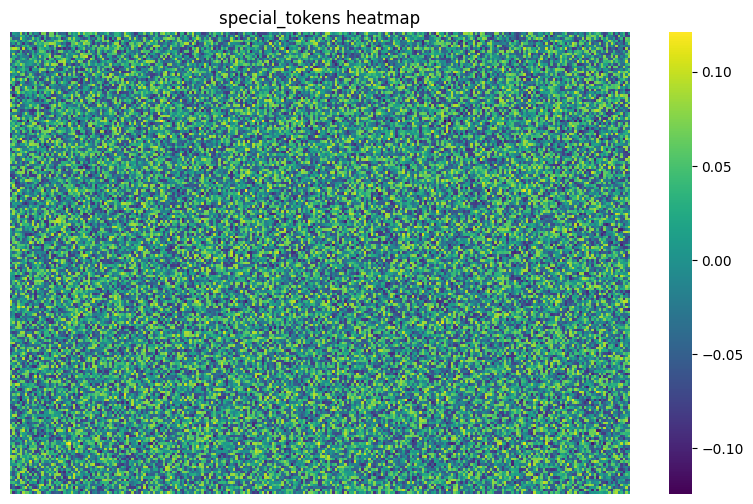

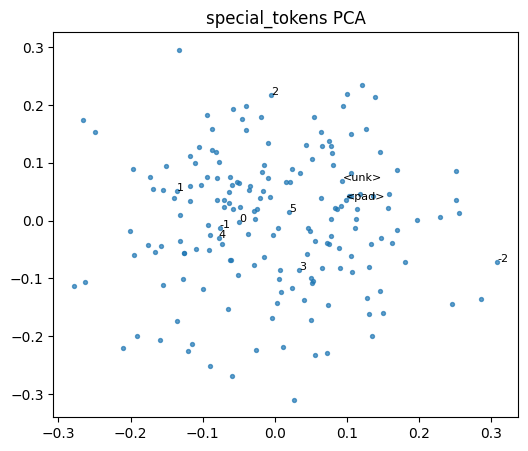

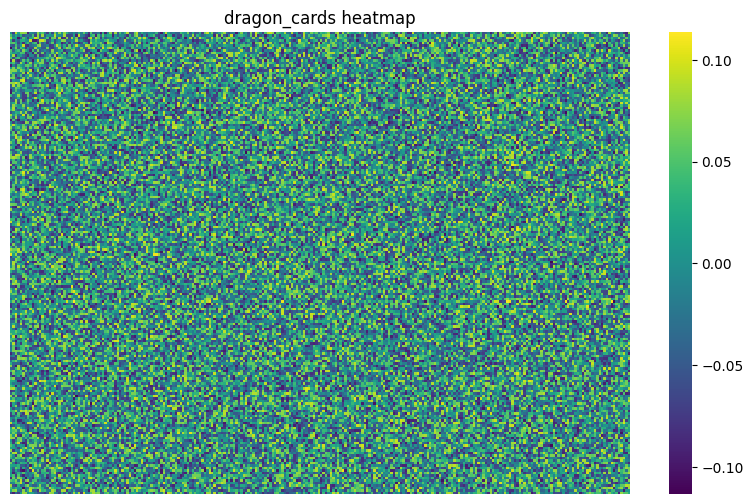

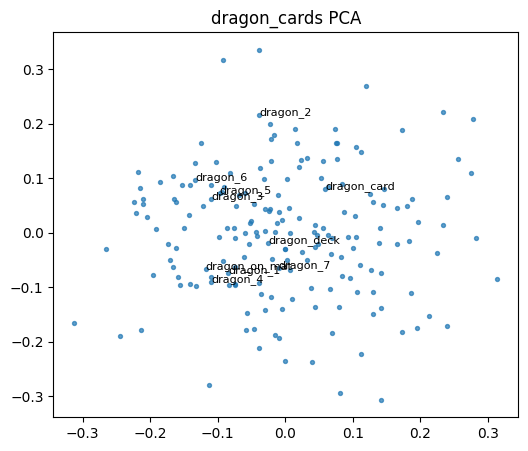

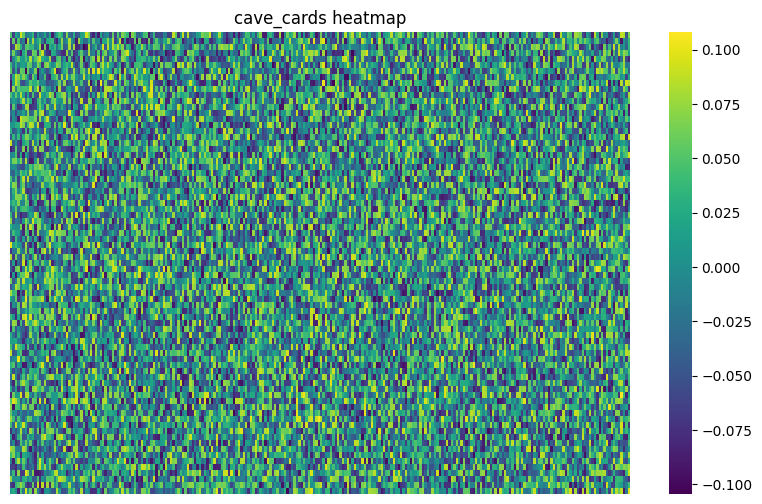

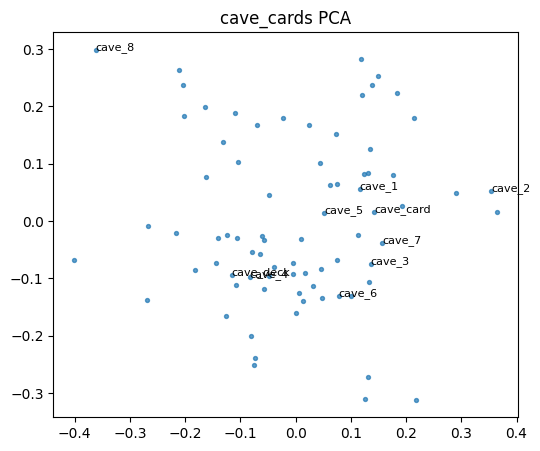

{'all_tokens': {'shape': (442, 256),
  'sample_tokens': ['<pad>',
   '<unk>',
   '-2',
   '-1',
   '0',
   '1',
   '2',
   '3',
   '4',
   '5']},
 'special_tokens': {'shape': (179, 256),
  'sample_tokens': ['<pad>',
   '<unk>',
   '-2',
   '-1',
   '0',
   '1',
   '2',
   '3',
   '4',
   '5']},
 'dragon_cards': {'shape': (186, 256),
  'sample_tokens': ['dragon_on_mat',
   'dragon_deck',
   'dragon_card',
   'dragon_1',
   'dragon_2',
   'dragon_3',
   'dragon_4',
   'dragon_5',
   'dragon_6',
   'dragon_7']},
 'cave_cards': {'shape': (77, 256),
  'sample_tokens': ['cave_deck',
   'cave_card',
   'cave_1',
   'cave_2',
   'cave_3',
   'cave_4',
   'cave_5',
   'cave_6',
   'cave_7',
   'cave_8']}}

In [3]:
model_path = r"checkpoints\ppo\ppo_update_180_2376960_eval_0.477.pt"
summary = visualize_token_embeddings(model_path)
summary